# Detección temprana de suplantación para un usuario

**Caso de estudio:** `user12` del conjunto Balabit.

> **Pregunta principal del proyecto.** ¿Qué tan bien las características temporales y cinemáticas del mouse permiten distinguir sesiones legítimas e impostoras en diez usuarios, y qué muestra el caso de `user12` sobre la posibilidad de detectar una suplantación de manera temprana?

Este notebook desarrolla el estudio de caso de `user12` y responde las dos preguntas específicas correspondientes:

1. En `user12`, ¿cómo cambia la detección al observar entre 25 y 150 eventos y existe un mínimo que satisfaga el criterio operativo?
2. En ese caso, ¿qué características discriminan mejor y qué tan estable es el comportamiento legítimo entre sesiones?

Una **interacción** significa aquí una fila registrada por el dataset: movimiento o evento de botón. Para simular detección temprana, cada sesión de test se observa solamente hasta sus primeros $N$ eventos.

### Qué hace este notebook

Este notebook se limita a entrenar, calibrar y evaluar el modelo del estudio de caso; no identifica personas ni ajusta el modelo con ejemplos de impostores. El flujo se ejecuta siempre en el mismo orden:

1. separar sesiones completas legítimas en enrolamiento y validación;
2. extraer ventanas no superpuestas para aprender el perfil;
3. ajustar `StandardScaler` e `Isolation Forest` solo con enrolamiento;
4. fijar el umbral con las ventanas legítimas de validación; y
5. evaluar un único prefijo por sesión pública de test.

Las celdas Markdown explican el propósito de cada etapa y los comentarios del código describen las operaciones que la implementan.


In [1]:
# Utilidades de Python para rutas, tipos, fórmulas y caché de archivos.
from functools import lru_cache
from pathlib import Path
from typing import Sequence
import math

# NumPy y Pandas realizan los cálculos y organizan las tablas.
import numpy as np
import pandas as pd
# Matplotlib y Seaborn construyen las gráficas.
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import Markdown, display
# Herramientas del modelo: escalado, Isolation Forest y AUC.
from sklearn.ensemble import IsolationForest
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import StandardScaler

RANDOM_STATE = 7                 # Repite siempre el mismo bosque aleatorio.
TARGET_USER = "user12"           # Usuario con 7 sesiones de training y test equilibrado.
TIME_COLUMN = "client timestamp" # Reloj usado para velocidad y aceleración.
# El máximo es 150 porque la sesión pública más corta de user12 tiene 172 eventos.
WINDOW_SIZES = [25, 50, 75, 100, 125, 150]
REFERENCE_SIZE = 100              # Ventana usada en los análisis detallados.
VALIDATION_FRACTION = 0.25        # Reserva 25% de las sesiones legítimas.
N_ESTIMATORS = 200                # Cantidad de árboles de Isolation Forest.
MAX_WINDOWS_PER_SESSION = 300     # Evita que una sesión muy larga domine el ajuste.

# Criterio operativo declarado antes de revisar el resultado final.
MIN_AUC = 0.80
MAX_FAR = 0.10       # impostores aceptados
MAX_FRR = 0.10       # legítimos enviados a alarma
MIN_COVERAGE = 1.00  # mismas sesiones para todos los tamaños
VALIDATION_QUANTILE = 1.0 - MAX_FRR  # percentil 90

np.random.seed(RANDOM_STATE)       # Hace reproducibles las operaciones de NumPy.
sns.set_theme(style="whitegrid")  # Estilo visual común para todas las figuras.

# Permite ejecutar desde la carpeta notebook/ o desde su carpeta superior.
candidates = [Path.cwd() / "data", Path.cwd() / "notebook" / "data"]
DATA_DIR = next((p.resolve() for p in candidates if (p / "public_labels.csv").exists()), None)
if DATA_DIR is None:
    raise FileNotFoundError(
        "No se encontró data/public_labels.csv. Ejecuta el notebook desde proyecto/notebook."
    )

print(f"Usuario: {TARGET_USER}")
print(f"Datos: {DATA_DIR}")
print(f"Ventanas evaluadas: {WINDOW_SIZES}")
print(f"Umbral: percentil {int(100 * VALIDATION_QUANTILE)} de validación legítima")


Usuario: user12
Datos: /Users/alech/Documents/notes/Obsidian/posgrado/master/MATEMÁTICAS Y PROGRAMACIÓN IA/proyecto/notebook/data
Ventanas evaluadas: [25, 50, 75, 100, 125, 150]
Umbral: percentil 90 de validación legítima


## 1. Sesiones utilizadas

Las sesiones de `training_files` son legítimas. En `user12`, cinco sesiones forman el enrolamiento y dos la validación. La separación se realiza antes de formar ventanas, por lo que las ventanas de una misma sesión nunca aparecen en ambos grupos.

Las etiquetas públicas de test se mantienen fuera del escalado, el entrenamiento y la calibración. Solo se consultan al final para calcular las métricas de una decisión por sesión.


In [2]:
# Carga las etiquetas públicas: 0 = legítimo y 1 = impostor.
labels = pd.read_csv(DATA_DIR / "public_labels.csv")
# Una etiqueta duplicada volvería ambigua la evaluación.
if labels["filename"].duplicated().any():
    raise ValueError("public_labels.csv contiene nombres duplicados")
# Diccionario para consultar rápidamente la etiqueta a partir del archivo.
label_map = dict(zip(labels["filename"], labels["is_illegal"].astype(int)))

# Busca los archivos pertenecientes únicamente al usuario seleccionado.
train_paths = sorted((DATA_DIR / "training_files" / TARGET_USER).glob("session_*"))
all_test_paths = sorted((DATA_DIR / "test_files" / TARGET_USER).glob("session_*"))
# Excluye sesiones privadas que no poseen etiqueta pública.
test_paths = [path for path in all_test_paths if path.name in label_map]

if len(train_paths) < 3 or not test_paths:
    raise ValueError(f"Datos insuficientes para {TARGET_USER}")

# Separa por sesiones completas para que ninguna ventana aparezca en ambos grupos.
validation_count = max(1, round(len(train_paths) * VALIDATION_FRACTION))
validation_count = min(validation_count, len(train_paths) - 2)
enroll_paths = train_paths[:-validation_count]
validation_paths = train_paths[-validation_count:]
# Estas etiquetas se guardan para evaluar después de fijar cada umbral.
y_test_all = np.asarray([label_map[path.name] for path in test_paths], dtype=int)

# Tabla sencilla para comprobar cuántas sesiones hay en cada grupo.
inventory = pd.DataFrame(
    {
        "Grupo": ["Enrolamiento legítimo", "Validación legítima", "Test legítimo", "Test impostor"],
        "Sesiones": [
            len(enroll_paths),
            len(validation_paths),
            int(np.sum(y_test_all == 0)),
            int(np.sum(y_test_all == 1)),
        ],
    }
)
display(inventory)


,Grupo,Sesiones
0,Enrolamiento legítimo,5
1,Validación legítima,2
2,Test legítimo,56
3,Test impostor,49


## 2. Características y ventanas

De cada ventana se extraen 15 características de duración, frecuencia de eventos, movimientos, clics, distancia, eficiencia, velocidad, aceleración, cambios angulares y pausas. Estas características resumen un número variable de eventos en un vector de longitud fija que el modelo puede procesar.

Para enrolamiento y validación se usan ventanas no superpuestas de sesiones legítimas, con un máximo de 300 por sesión para evitar que una sesión extensa domine el ajuste. Para test se usa únicamente el prefijo formado por los primeros $N$ eventos de cada sesión; así, cada combinación de sesión y tamaño produce una sola decisión.


In [3]:
# Orden exacto de las 15 columnas del vector que recibirá el modelo.
FEATURE_NAMES = [
    "duration_s",
    "event_rate_hz",
    "move_fraction",
    "button_event_fraction",
    "path_length_px",
    "net_displacement_px",
    "path_efficiency",
    "speed_mean",
    "speed_std",
    "speed_max",
    "acceleration_abs_mean",
    "acceleration_abs_std",
    "angle_change_abs_mean",
    "pause_fraction",
    "valid_segment_fraction",
]

# Nombres legibles que se mostrarán en tablas y gráficas.
FEATURE_LABELS = {
    "duration_s": "Duración",
    "event_rate_hz": "Frecuencia de eventos",
    "move_fraction": "Fracción de movimientos",
    "button_event_fraction": "Fracción de eventos de botón",
    "path_length_px": "Longitud de trayectoria",
    "net_displacement_px": "Desplazamiento neto",
    "path_efficiency": "Eficiencia de trayectoria",
    "speed_mean": "Velocidad media",
    "speed_std": "Variación de velocidad",
    "speed_max": "Velocidad máxima",
    "acceleration_abs_mean": "Aceleración media absoluta",
    "acceleration_abs_std": "Variación de aceleración",
    "angle_change_abs_mean": "Cambio angular medio",
    "pause_fraction": "Fracción de pausas",
    "valid_segment_fraction": "Segmentos temporales válidos",
}


@lru_cache(maxsize=None)
def load_events(path: Path) -> pd.DataFrame:
    '''Lee una sesión una sola vez, valida sus datos y la conserva en memoria.'''
    # Solo se cargan las cinco columnas necesarias para reducir memoria.
    columns = [TIME_COLUMN, "button", "state", "x", "y"]
    frame = pd.read_csv(path, usecols=columns)
    if len(frame) < 2:
        raise ValueError(f"La sesión necesita al menos dos eventos: {path}")
    # Convierte tiempo y coordenadas a números; un dato inválido genera error.
    for column in [TIME_COLUMN, "x", "y"]:
        frame[column] = pd.to_numeric(frame[column], errors="raise")
    numeric = frame[[TIME_COLUMN, "x", "y"]].to_numpy(dtype=float)
    # NaN o infinito producirían velocidades y distancias incorrectas.
    if not np.isfinite(numeric).all():
        raise ValueError(f"Valores no finitos en {path}")
    return frame


def extract_features(frame: pd.DataFrame) -> np.ndarray:
    '''Convierte una ventana de eventos en 15 resúmenes temporales y cinemáticos.'''
    # Se separan las columnas como arreglos para calcular diferencias rápidamente.
    t = frame[TIME_COLUMN].to_numpy(dtype=float)
    x = frame["x"].to_numpy(dtype=float)
    y = frame["y"].to_numpy(dtype=float)
    states = frame["state"].astype(str).str.lower().to_numpy()
    buttons = frame["button"].astype(str).str.lower().to_numpy()

    # Orden estable dentro del fragmento; los empates conservan el orden de captura.
    order = np.argsort(t, kind="stable")
    t, x, y = t[order], x[order], y[order]
    states, buttons = states[order], buttons[order]

    # Diferencias entre eventos consecutivos: tiempo, posición y distancia.
    dt = np.diff(t)
    dx, dy = np.diff(x), np.diff(y)
    distances = np.hypot(dx, dy)
    # Solo dt > 0 permite dividir de forma válida para obtener velocidad.
    valid_time = dt > 0.0
    speeds = distances[valid_time] / dt[valid_time]
    speed_times = t[1:][valid_time]

    # Aceleración absoluta = cambio de velocidad / cambio de tiempo.
    if len(speeds) > 1:
        acceleration_dt = np.diff(speed_times)
        valid_acceleration = acceleration_dt > 0.0
        accelerations = (
            np.abs(np.diff(speeds)[valid_acceleration])
            / acceleration_dt[valid_acceleration]
        )
    else:
        accelerations = np.array([], dtype=float)

    # Los ángulos describen la dirección; su diferencia mide los giros.
    valid_direction = valid_time & (distances > 0.0)
    angles = np.arctan2(dy[valid_direction], dx[valid_direction])
    angle_changes = (
        np.abs((np.diff(angles) + np.pi) % (2.0 * np.pi) - np.pi)
        if len(angles) > 1
        else np.array([], dtype=float)
    )

    # Resúmenes globales de duración y geometría de la trayectoria.
    duration = max(0.0, float(t[-1] - t[0]))
    path_length = float(np.sum(distances))
    displacement = float(math.hypot(x[-1] - x[0], y[-1] - y[0]))
    segments = len(frame) - 1

    # Todas las ventanas terminan representadas por un vector de igual longitud.
    values = np.array(
        [
            duration,  # segundos cubiertos por la ventana
            len(frame) / duration if duration > 0.0 else 0.0,  # eventos por segundo
            float(np.mean(states == "move")),  # proporción de movimientos
            float(np.mean((buttons != "nobutton") | (states != "move"))),  # eventos de botón
            path_length,  # suma de todas las distancias recorridas
            displacement,  # distancia directa entre inicio y final
            displacement / path_length if path_length > 0.0 else 0.0,  # eficiencia
            float(np.mean(speeds)) if len(speeds) else 0.0,  # velocidad media
            float(np.std(speeds)) if len(speeds) > 1 else 0.0,  # variación de velocidad
            float(np.max(speeds)) if len(speeds) else 0.0,  # velocidad máxima
            float(np.mean(accelerations)) if len(accelerations) else 0.0,  # aceleración media
            float(np.std(accelerations)) if len(accelerations) > 1 else 0.0,  # variación de aceleración
            float(np.mean(angle_changes)) if len(angle_changes) else 0.0,  # giros medios
            float(np.sum(dt >= 0.5) / segments),  # pausas de al menos 0.5 segundos
            float(np.sum(valid_time) / segments),  # intervalos con tiempo creciente
        ],
        dtype=float,
    )
    if values.shape != (len(FEATURE_NAMES),) or not np.isfinite(values).all():
        raise AssertionError("Vector de características inválido")
    return values


def window_starts(length: int, size: int) -> np.ndarray:
    '''Devuelve inicios de ventanas no superpuestas de `size` eventos.'''
    starts = np.arange(0, length - size + 1, size, dtype=int)
    # Si hay demasiadas, toma posiciones repartidas por toda la sesión.
    if len(starts) > MAX_WINDOWS_PER_SESSION:
        positions = np.linspace(0, len(starts) - 1, MAX_WINDOWS_PER_SESSION)
        starts = starts[np.unique(np.rint(positions).astype(int))]
    return starts


def session_window_matrix(path: Path, size: int) -> np.ndarray:
    '''Transforma todas las ventanas utilizables de una sesión en una matriz.'''
    frame = load_events(path)
    starts = window_starts(len(frame), size)
    if not len(starts):
        return np.empty((0, len(FEATURE_NAMES)))
    return np.vstack(
        [extract_features(frame.iloc[start : start + size]) for start in starts]
    )


def training_window_matrix(paths: Sequence[Path], size: int) -> np.ndarray:
    '''Une verticalmente las matrices de varias sesiones legítimas.'''
    matrices = [session_window_matrix(path, size) for path in paths]
    matrices = [matrix for matrix in matrices if len(matrix)]
    if not matrices:
        raise ValueError(f"No hay ventanas de {size} eventos")
    return np.vstack(matrices)


def prefix_features(path: Path, size: int) -> tuple[np.ndarray, float] | None:
    '''Extrae las características de los primeros `size` eventos de una sesión.'''
    frame = load_events(path)
    # Una sesión corta no puede evaluarse con una ventana mayor que su longitud.
    if len(frame) < size:
        return None
    prefix = frame.iloc[:size]
    # Además del vector se devuelve cuánto tiempo tomó observar ese prefijo.
    timestamps = prefix[TIME_COLUMN].to_numpy(dtype=float)
    elapsed = max(0.0, float(np.max(timestamps) - np.min(timestamps)))
    return extract_features(prefix), elapsed


## 3. Evaluación según el número de interacciones

Para cada tamaño se ajusta y calibra un modelo nuevo. El procedimiento es: construir las ventanas legítimas, ajustar el escalador, entrenar el bosque, calcular el umbral con validación y, por último, puntuar los prefijos de test. Una configuración se marca como **confiable dentro de este experimento** si alcanza simultáneamente AUC $\geq 0.80$, FAR $\leq 0.10$, FRR $\leq 0.10$ y cobertura total.

### Razón del umbral escogido

Se usa el **percentil 90 de los scores legítimos de validación**. El percentil 95 anterior reservaba solamente un 5% para falsas alarmas, aunque el criterio declarado permite hasta un 10%. El percentil 90 utiliza ese margen adicional para aumentar la sensibilidad. La opción `method="higher"` elige un score realmente observado y evita que la interpolación reduzca artificialmente el umbral. Las etiquetas de test no intervienen en el cálculo numérico del umbral.

La decisión es `alarma = score > umbral`, donde un score alto significa mayor anomalía:

- **Subir el umbral:** genera menos alarmas; rechaza menos legítimos, pero deja pasar más impostores.
- **Bajar el umbral:** genera más alarmas; detecta más impostores, pero puede molestar a más usuarios legítimos.

En esta versión **no se subió el umbral**: se bajó del percentil 95 al 90. Primero se calcula ese valor usando únicamente ventanas legítimas de validación; después se mantiene fijo y recién entonces se consultan las etiquetas de test para medir TP, FP, FN y TN.


In [4]:
def classification_metrics(y_true: Sequence[int], prediction: Sequence[int]) -> dict[str, float | int]:
    '''Calcula aciertos, errores y métricas usando impostor como clase positiva.'''
    y = np.asarray(y_true, dtype=int)
    pred = np.asarray(prediction, dtype=int)
    # TP: impostor detectado; FN: impostor aceptado.
    # FP: legítimo en alarma; TN: legítimo aceptado.
    tp = int(np.sum((y == 1) & (pred == 1)))
    fp = int(np.sum((y == 0) & (pred == 1)))
    fn = int(np.sum((y == 1) & (pred == 0)))
    tn = int(np.sum((y == 0) & (pred == 0)))
    far = fn / (tp + fn) if tp + fn else np.nan  # Riesgo de seguridad.
    frr = fp / (tn + fp) if tn + fp else np.nan  # Costo para el legítimo.
    precision = tp / (tp + fp) if tp + fp else 0.0
    recall = tp / (tp + fn) if tp + fn else 0.0
    f1 = 2.0 * precision * recall / (precision + recall) if precision + recall else 0.0
    return {
        "TP": tp,
        "FP": fp,
        "FN": fn,
        "TN": tn,
        "FAR": float(far),
        "FRR": float(frr),
        "Detección impostor": float(recall),
        "F1 impostor": float(f1),
        "Pérdida balanceada": float(0.5 * (far + frr)),
    }


def evaluate_size(size: int) -> tuple[dict, dict]:
    '''Entrena, calibra y evalúa Isolation Forest para un tamaño de ventana.'''
    # Las ventanas de enrolamiento ajustan el escalador y el bosque.
    X_enroll = training_window_matrix(enroll_paths, size)
    # Las ventanas de validación solo determinan el umbral.
    X_validation = training_window_matrix(validation_paths, size)

    # Aprende media y desviación únicamente a partir del enrolamiento.
    scaler = StandardScaler().fit(X_enroll)
    Z_enroll = scaler.transform(X_enroll)
    # Isolation Forest aprende qué aspecto tiene el comportamiento legítimo.
    forest = IsolationForest(
        n_estimators=N_ESTIMATORS,
        contamination="auto",
        random_state=RANDOM_STATE,
        n_jobs=-1,
    ).fit(Z_enroll)

    # Se cambia el signo para que score alto siempre signifique más anomalía.
    validation_scores = -forest.score_samples(scaler.transform(X_validation))
    # El percentil 90 deja aproximadamente 10% de validación sobre el umbral.
    # Aquí todavía no se usa y_test ni ninguna etiqueta del test.
    threshold = float(
        np.quantile(validation_scores, VALIDATION_QUANTILE, method="higher")
    )

    # Construye un único prefijo temprano por cada sesión pública de test.
    eligible_paths = []
    features = []
    elapsed_seconds = []
    for path in test_paths:
        result = prefix_features(path, size)
        if result is not None:
            vector, elapsed = result
            eligible_paths.append(path)
            features.append(vector)
            elapsed_seconds.append(elapsed)

    X_test = np.vstack(features)
    # Las etiquetas aparecen recién aquí, después de dejar fijo el umbral.
    y_test = np.asarray([label_map[path.name] for path in eligible_paths], dtype=int)
    scores = -forest.score_samples(scaler.transform(X_test))
    # Regla de decisión: 1 = alarma cuando el score supera el umbral.
    prediction = (scores > threshold).astype(int)
    metrics = classification_metrics(y_test, prediction)
    auc = float(roc_auc_score(y_test, scores))
    coverage = len(eligible_paths) / len(test_paths)
    # Exige simultáneamente buena separación, pocos errores y cobertura total.
    reliable = (
        auc >= MIN_AUC
        and metrics["FAR"] <= MAX_FAR
        and metrics["FRR"] <= MAX_FRR
        and coverage >= MIN_COVERAGE
    )

    # `row` contiene lo que se mostrará en la tabla comparativa.
    row = {
        "Eventos": size,
        "Tiempo mediano (s)": float(np.median(elapsed_seconds)),
        "Cobertura": coverage,
        "Umbral": threshold,
        "AUC": auc,
        **metrics,
        "Confiable": reliable,
    }
    # `artifacts` conserva objetos necesarios para análisis posteriores.
    artifacts = {
        "scaler": scaler,
        "forest": forest,
        "threshold": threshold,
        "X_test": X_test,
        "y_test": y_test,
        "scores": scores,
        "eligible_paths": eligible_paths,
        "enroll_windows": len(X_enroll),
        "validation_windows": len(X_validation),
    }
    return row, artifacts


# Ejecuta exactamente el mismo procedimiento para cada cantidad de eventos.
rows = []
artifacts_by_size = {}
for size in WINDOW_SIZES:
    row, artifacts = evaluate_size(size)
    rows.append(row)
    artifacts_by_size[size] = artifacts
    print(f"✓ {size:3d} eventos: AUC={row['AUC']:.3f}, FAR={row['FAR']:.1%}, FRR={row['FRR']:.1%}")

# Convierte la lista de resultados en una tabla de Pandas.
results = pd.DataFrame(rows)
display_columns = [
    "Eventos",
    "Tiempo mediano (s)",
    "Cobertura",
    "Umbral",
    "AUC",
    "Detección impostor",
    "FAR",
    "FRR",
    "F1 impostor",
    "Confiable",
]
display(
    results[display_columns].round(
        {
            "Tiempo mediano (s)": 1,
            "Cobertura": 3,
            "Umbral": 3,
            "AUC": 3,
            "Detección impostor": 3,
            "FAR": 3,
            "FRR": 3,
            "F1 impostor": 3,
        }
    )
)


✓  25 eventos: AUC=0.632, FAR=81.6%, FRR=7.1%
✓  50 eventos: AUC=0.652, FAR=75.5%, FRR=5.4%
✓  75 eventos: AUC=0.651, FAR=71.4%, FRR=8.9%
✓ 100 eventos: AUC=0.692, FAR=69.4%, FRR=3.6%
✓ 125 eventos: AUC=0.665, FAR=67.3%, FRR=7.1%
✓ 150 eventos: AUC=0.673, FAR=75.5%, FRR=5.4%


,Eventos,Tiempo mediano (s),Cobertura,Umbral,AUC,Detección impostor,FAR,FRR,F1 impostor,Confiable
0,25,3.9,1.0,0.498,0.632,0.184,0.816,0.071,0.290,False
1,50,9.7,1.0,0.499,0.652,0.245,0.755,0.054,0.375,False
2,75,16.9,1.0,0.484,0.651,0.286,0.714,0.089,0.412,False
3,100,23.1,1.0,0.481,0.692,0.306,0.694,0.036,0.455,False
4,125,31.1,1.0,0.472,0.665,0.327,0.673,0.071,0.464,False
5,150,37.2,1.0,0.472,0.673,0.245,0.755,0.054,0.375,False


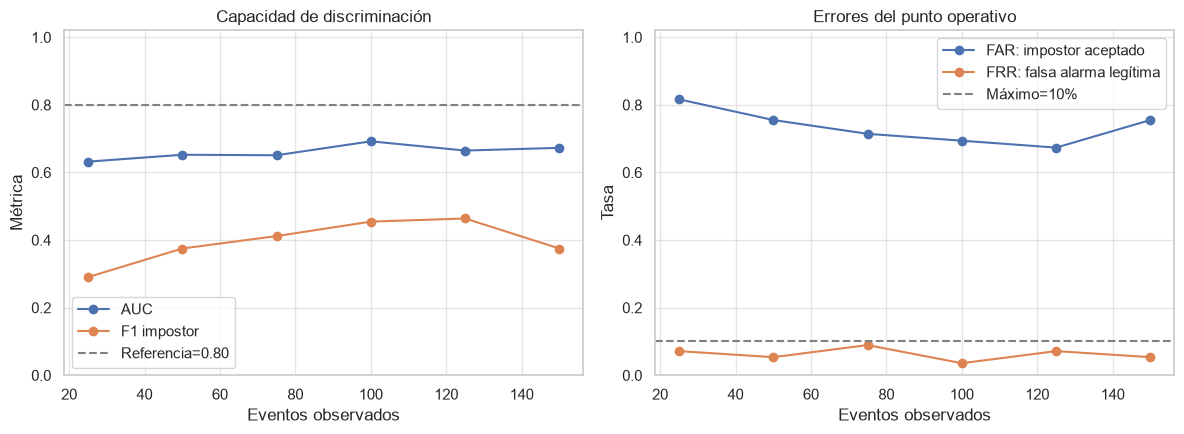

In [5]:
# Dos paneles evitan mezclar métricas donde "mayor" y "menor" significan cosas distintas.
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# Izquierda: AUC y F1 deben crecer.
axes[0].plot(results["Eventos"], results["AUC"], marker="o", label="AUC")
axes[0].plot(results["Eventos"], results["F1 impostor"], marker="o", label="F1 impostor")
axes[0].axhline(MIN_AUC, color="gray", linestyle="--", label=f"Referencia={MIN_AUC:.2f}")
axes[0].set(title="Capacidad de discriminación", xlabel="Eventos observados", ylabel="Métrica", ylim=(0, 1.02))
axes[0].legend()

# Derecha: FAR y FRR deben disminuir; la línea marca el máximo permitido.
axes[1].plot(results["Eventos"], results["FAR"], marker="o", label="FAR: impostor aceptado")
axes[1].plot(results["Eventos"], results["FRR"], marker="o", label="FRR: falsa alarma legítima")
axes[1].axhline(MAX_FAR, color="gray", linestyle="--", label=f"Máximo={MAX_FAR:.0%}")
axes[1].set(title="Errores del punto operativo", xlabel="Eventos observados", ylabel="Tasa", ylim=(0, 1.02))
axes[1].legend()

plt.tight_layout()
plt.show()


## 4. Características que mejor discriminan

Se usa una ventana fija de 100 eventos y se calcula el AUC individual de cada característica. El valor se orienta para medir fuerza discriminante sin importar si los impostores presentan valores mayores o menores. Es un diagnóstico descriptivo, no una selección usada para reajustar el modelo.


,Característica,AUC individual,Dirección en impostores,Mediana legítima,Mediana impostora
11,Variación de aceleración,0.769,mayor,4433.022,9707.450
10,Aceleración media absoluta,0.743,mayor,2844.057,4809.817
9,Velocidad máxima,0.665,mayor,3273.308,5095.940
8,Variación de velocidad,0.657,mayor,639.502,866.590
2,Fracción de movimientos,0.626,menor,0.890,0.860
3,Fracción de eventos de botón,0.626,mayor,0.110,0.140
12,Cambio angular medio,0.602,mayor,0.663,0.752
7,Velocidad media,0.601,mayor,387.344,429.278


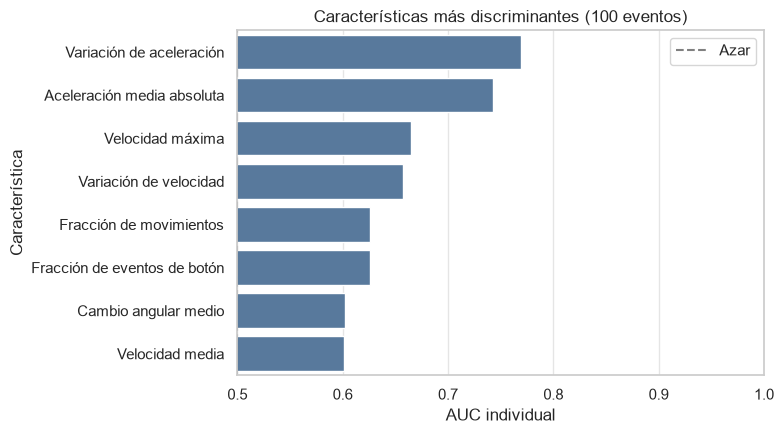

In [6]:
# Recupera las predicciones de la ventana de referencia de 100 eventos.
reference = artifacts_by_size[REFERENCE_SIZE]
X_reference = reference["X_test"]
y_reference = reference["y_test"]

# Evalúa cada característica por separado, sin volver a entrenar el modelo.
feature_rows = []
for index, feature in enumerate(FEATURE_NAMES):
    values = X_reference[:, index]
    # AUC=0.5 no discrimina; cuanto más se acerca a 1, mejor separa las clases.
    raw_auc = float(roc_auc_score(y_reference, values)) if len(np.unique(values)) > 1 else 0.5
    feature_rows.append(
        {
            "Característica": FEATURE_LABELS[feature],
            # Orienta el AUC para medir fuerza aunque el impostor tenga valores menores.
            "AUC individual": max(raw_auc, 1.0 - raw_auc),
            "Dirección en impostores": "mayor" if raw_auc >= 0.5 else "menor",
            "Mediana legítima": float(np.median(values[y_reference == 0])),
            "Mediana impostora": float(np.median(values[y_reference == 1])),
        }
    )

# Ordena de la característica más discriminante a la menos discriminante.
feature_ranking = pd.DataFrame(feature_rows).sort_values("AUC individual", ascending=False)
top_features = feature_ranking.head(8)
display(top_features.round(3))

plt.figure(figsize=(8, 4.5))
sns.barplot(data=top_features, y="Característica", x="AUC individual", color="#4C78A8")
plt.axvline(0.5, color="gray", linestyle="--", label="Azar")
plt.xlim(0.5, 1.0)
plt.title(f"Características más discriminantes ({REFERENCE_SIZE} eventos)")
plt.legend()
plt.tight_layout()
plt.show()


## 5. Estabilidad del usuario legítimo entre sesiones

Con el modelo de 100 eventos se comparan los scores de ventanas legítimas de cada sesión. Las sesiones de validación son especialmente informativas porque no participaron en el ajuste.


,Sesión,Rol,Ventanas,Score mediano,Score p95,Tasa de alarma
0,2144641057,Enrolamiento,300,0.397,0.514,0.090
1,5265929106,Enrolamiento,300,0.399,0.508,0.123
2,5815391283,Enrolamiento,300,0.394,0.501,0.063
3,7409188284,Enrolamiento,300,0.429,0.532,0.180
4,8872593360,Enrolamiento,300,0.393,0.498,0.083
5,9031593624,Validación,300,0.392,0.498,0.073
6,9838420452,Validación,297,0.400,0.531,0.125


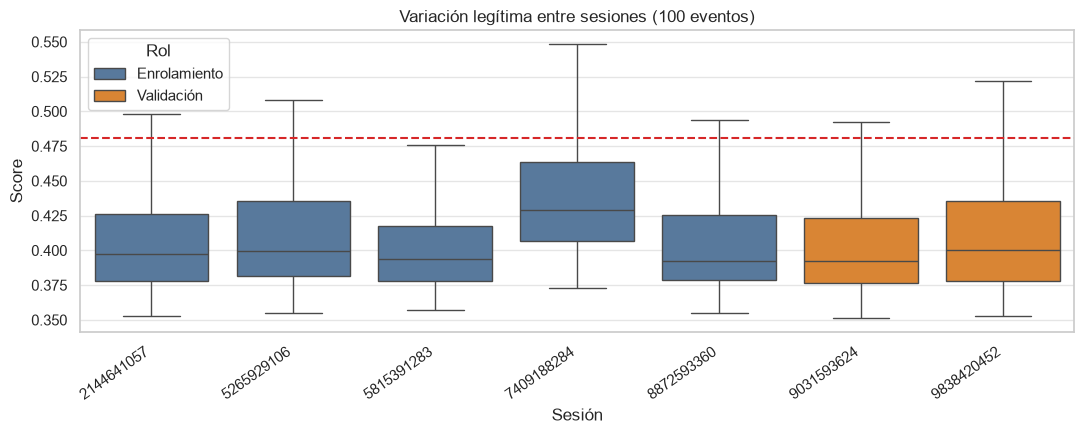

In [7]:
# Reutiliza el modelo de 100 eventos; no se vuelve a ajustar en esta sección.
scaler = reference["scaler"]
forest = reference["forest"]
threshold = reference["threshold"]
stability_rows = []
score_rows = []

# Puntúa por separado cada sesión legítima para observar cambios entre sesiones.
for path in train_paths:
    matrix = session_window_matrix(path, REFERENCE_SIZE)
    scores = -forest.score_samples(scaler.transform(matrix))
    # Distingue sesiones vistas por el modelo de sesiones reservadas.
    role = "Validación" if path in validation_paths else "Enrolamiento"
    stability_rows.append(
        {
            "Sesión": path.name.replace("session_", ""),
            "Rol": role,
            "Ventanas": len(scores),
            "Score mediano": float(np.median(scores)),
            "Score p95": float(np.quantile(scores, 0.95)),
            "Tasa de alarma": float(np.mean(scores > threshold)),
        }
    )
    score_rows.extend(
        {
            "Sesión": path.name.replace("session_", ""),
            "Rol": role,
            "Score": float(score),
        }
        for score in scores
    )

stability = pd.DataFrame(stability_rows)
score_frame = pd.DataFrame(score_rows)
display(stability.round({"Score mediano": 3, "Score p95": 3, "Tasa de alarma": 3}))

plt.figure(figsize=(11, 4.5))
sns.boxplot(
    data=score_frame,
    x="Sesión",
    y="Score",
    hue="Rol",
    dodge=False,
    palette={"Enrolamiento": "#4C78A8", "Validación": "#F58518"},
    showfliers=False,
)
plt.axhline(threshold, color="#D62728", linestyle="--", label="Umbral")
plt.title(f"Variación legítima entre sesiones ({REFERENCE_SIZE} eventos)")
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
plt.show()


## 6. Respuesta final

La siguiente celda genera una respuesta breve a partir de las evaluaciones, evitando escribir manualmente valores que podrían cambiar al modificar el usuario o las ventanas.


In [8]:
# Filtra los tamaños que cumplieron todos los criterios declarados.
reliable_rows = results[results["Confiable"]]
# Si ninguno cumple, este es el menor error medio entre FAR y FRR.
best_row = results.loc[results["Pérdida balanceada"].idxmin()]
first_row = results.iloc[0]
last_row = results.iloc[-1]
top_three = ", ".join(feature_ranking.head(3)["Característica"].str.lower())

# Resume cuánto varió la alarma entre sesiones legítimas.
validation_stability = stability[stability["Rol"] == "Validación"]
alarm_min = float(stability["Tasa de alarma"].min())
alarm_max = float(stability["Tasa de alarma"].max())
validation_alarm_min = float(validation_stability["Tasa de alarma"].min())
validation_alarm_max = float(validation_stability["Tasa de alarma"].max())
stability_text = (
    "la variación entre sesiones fue reducida"
    if alarm_max - alarm_min <= 0.05
    else "se observó variación entre sesiones"
)

# Construye una frase diferente según exista o no un mínimo confiable.
if reliable_rows.empty:
    minimum_text = (
        f"Ninguna ventana entre {WINDOW_SIZES[0]} y {WINDOW_SIZES[-1]} eventos cumplió "
        f"simultáneamente AUC≥{MIN_AUC:.2f}, FAR≤{MAX_FAR:.0%} y FRR≤{MAX_FRR:.0%}."
    )
else:
    minimum = int(reliable_rows.iloc[0]["Eventos"])
    minimum_text = f"El mínimo que cumplió el criterio fue **{minimum} eventos**."

# Inserta automáticamente los valores calculados para evitar texto desactualizado.
conclusion = f'''        ### Resultado para {TARGET_USER}

- **Umbral:** se utilizó el percentil {int(100 * VALIDATION_QUANTILE)} de validación legítima porque coincide con el máximo permitido de {MAX_FRR:.0%} de falsas alarmas y busca mayor sensibilidad que el percentil 95, sin consultar las etiquetas de test.
- **Características:** las tres señales individuales más discriminantes a {REFERENCE_SIZE} eventos fueron {top_three}.
- **Tamaño de ventana:** al pasar de {int(first_row['Eventos'])} a {int(last_row['Eventos'])} eventos, el AUC cambió de {first_row['AUC']:.3f} a {last_row['AUC']:.3f}; la FAR cambió de {first_row['FAR']:.1%} a {last_row['FAR']:.1%} y la FRR de {first_row['FRR']:.1%} a {last_row['FRR']:.1%}.
- **Mínimo confiable:** {minimum_text}
- **Estabilidad legítima:** la tasa de alarma varió entre {alarm_min:.1%} y {alarm_max:.1%} en las siete sesiones; en las dos sesiones no usadas para ajustar estuvo entre {validation_alarm_min:.1%} y {validation_alarm_max:.1%}. Por tanto, {stability_text}.

**Respuesta principal.** El mejor compromiso observado ocurrió con **{int(best_row['Eventos'])} eventos**: AUC={best_row['AUC']:.3f}, detección de impostores={best_row['Detección impostor']:.1%} y falsas alarmas legítimas={best_row['FRR']:.1%}. Este resultado describe solamente a `{TARGET_USER}` y no implica que el criterio de confiabilidad se haya alcanzado.
'''
conclusion = conclusion.lstrip()
display(Markdown(conclusion))


### Resultado para user12

- **Umbral:** se utilizó el percentil 90 de validación legítima porque coincide con el máximo permitido de 10% de falsas alarmas y busca mayor sensibilidad que el percentil 95, sin consultar las etiquetas de test.
- **Características:** las tres señales individuales más discriminantes a 100 eventos fueron variación de aceleración, aceleración media absoluta, velocidad máxima.
- **Tamaño de ventana:** al pasar de 25 a 150 eventos, el AUC cambió de 0.632 a 0.673; la FAR cambió de 81.6% a 75.5% y la FRR de 7.1% a 5.4%.
- **Mínimo confiable:** Ninguna ventana entre 25 y 150 eventos cumplió simultáneamente AUC≥0.80, FAR≤10% y FRR≤10%.
- **Estabilidad legítima:** la tasa de alarma varió entre 6.3% y 18.0% en las siete sesiones; en las dos sesiones no usadas para ajustar estuvo entre 7.3% y 12.5%. Por tanto, se observó variación entre sesiones.

**Respuesta principal.** El mejor compromiso observado ocurrió con **100 eventos**: AUC=0.692, detección de impostores=30.6% y falsas alarmas legítimas=3.6%. Este resultado describe solamente a `user12` y no implica que el criterio de confiabilidad se haya alcanzado.


> **Alcance.** El resultado corresponde a un solo usuario, ataques simulados y una única decisión al observar los primeros $N$ eventos. Las ventanas de una misma sesión no se tratan como sesiones independientes.
